In [1]:
import gc
import torch

# 先清理一下可能残留的显存缓存，减少前一个 notebook 对当前训练的影响。
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    print('GPU cache cleared.')
else:
    print('CUDA not available, skip GPU cache clear.')


GPU cache cleared.


# 下一课：REINFORCE with Baseline

上一课我们学了最基础的 `REINFORCE`，已经理解了策略梯度的主线。

这一课我们继续补上一个非常关键的改进：`baseline`。

它的目标很明确：

**降低 REINFORCE 的方差，让训练更稳定。**


## 1. 为什么纯 REINFORCE 不太稳

在纯 REINFORCE 里，我们直接用 return `G_t` 去更新动作概率：

`loss ~ -log_prob * G_t`

问题是：
- `G_t` 的波动很大
- 同样一个动作，有时会因为后面轨迹不同而拿到很不一样的回报
- 这样梯度噪声会很大，训练容易抖

所以我们想要的不只是“回报高不高”，而是：

**这一步动作比一个合理基准好多少。**


## 2. baseline 的直觉

baseline 可以理解成“参考线”。

如果某一步的回报只是普通水平，那没必要特别激动地奖励它；
如果某一步明显比平均水平好，那才值得大力鼓励。

所以我们把更新信号从：
- `G_t`

改成：
- `G_t - baseline`

这个量通常叫做 `advantage`，优势函数的最朴素版本。


## 3. 这节课怎么做 baseline

最标准的思路之一是：
- 再加一个 value 网络
- 让它预测当前状态的价值 `V(s)`
- 然后用 `G_t - V(s)` 作为策略更新信号

也就是说：
- `policy_net` 负责决定动作概率
- `value_net` 负责给出这个状态的基准分

这已经很接近后面的 `Actor-Critic` 思想了。


In [2]:
import random
import warnings

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=3, suppress=True)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)


In [3]:
def pick_device():
    if torch.cuda.is_available():
        try:
            _ = torch.zeros(1, device='cuda')
            return torch.device('cuda')
        except Exception as e:
            warnings.warn(f'检测到 CUDA，但当前环境无法真正使用 GPU，已回退到 CPU。原因: {e}')
    return torch.device('cpu')


device = pick_device()
print('当前设备:', device)
if torch.cuda.is_available():
    print('检测到 CUDA 设备:', torch.cuda.get_device_name(0))


当前设备: cuda
检测到 CUDA 设备: NVIDIA GeForce RTX 5090


In [4]:
env = gym.make('CartPole-v1')
state, info = env.reset(seed=42)
print('初始状态:', state)
print('状态维度:', env.observation_space.shape[0])
print('动作数量:', env.action_space.n)


初始状态: [ 0.027 -0.006  0.036  0.02 ]
状态维度: 4
动作数量: 2


In [5]:
def to_tensor(x, device):
    return torch.tensor(x, dtype=torch.float32, device=device)


class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, x):
        return self.net(x)


class ValueNetwork(nn.Module):
    def __init__(self, state_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)


In [6]:
def compute_returns(rewards, gamma=0.99):
    returns = []
    G = 0.0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    return torch.tensor(returns, dtype=torch.float32)


## 4. 训练 REINFORCE + Baseline

这节课你要重点看两件事：

1. `policy_loss`
   不再直接乘 `G_t`，而是乘 `advantage = G_t - V(s)`

2. `value_loss`
   value 网络要学习去拟合 return，也就是让 `V(s)` 尽量接近 `G_t`

所以这一课其实同时在训练两个网络：
- 策略网络
- 价值网络


In [7]:
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

policy_net = PolicyNetwork(state_dim, action_dim, hidden_dim=128).to(device)
value_net = ValueNetwork(state_dim, hidden_dim=128).to(device)

policy_optimizer = optim.Adam(policy_net.parameters(), lr=1e-3)
value_optimizer = optim.Adam(value_net.parameters(), lr=1e-3)
value_criterion = nn.MSELoss()

gamma = 0.99
episodes = 400
max_steps = 500

episode_rewards = []
policy_loss_history = []
value_loss_history = []

for episode in range(episodes):
    state, info = env.reset()
    states = []
    log_probs = []
    rewards = []
    total_reward = 0.0

    for step in range(max_steps):
        state_tensor = to_tensor(state, device).unsqueeze(0)
        logits = policy_net(state_tensor)
        dist = Categorical(logits=logits)

        action = dist.sample()
        log_prob = dist.log_prob(action)

        next_state, reward, terminated, truncated, info = env.step(int(action.item()))
        done = terminated or truncated

        states.append(state)
        log_probs.append(log_prob)
        rewards.append(reward)
        total_reward += reward
        state = next_state

        if done:
            break

    returns = compute_returns(rewards, gamma=gamma).to(device)
    states_tensor = to_tensor(np.array(states), device)

    # value 网络预测每个状态的 baseline
    values = value_net(states_tensor).squeeze(1)

    # advantage = 实际回报 - baseline
    advantages = returns - values.detach()

    # 策略网络根据 advantage 更新。
    # 如果某一步比 baseline 更好，优势为正，就增加当时动作的概率。
    policy_loss = []
    for log_prob, advantage in zip(log_probs, advantages):
        policy_loss.append(-log_prob * advantage)
    policy_loss = torch.stack(policy_loss).sum()

    # value 网络要学会预测 return，作为 baseline。
    value_loss = value_criterion(values, returns)

    policy_optimizer.zero_grad()
    policy_loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=10.0)
    policy_optimizer.step()

    value_optimizer.zero_grad()
    value_loss.backward()
    torch.nn.utils.clip_grad_norm_(value_net.parameters(), max_norm=10.0)
    value_optimizer.step()

    episode_rewards.append(total_reward)
    policy_loss_history.append(float(policy_loss.item()))
    value_loss_history.append(float(value_loss.item()))

print('训练完成。')
print('最后 20 轮平均 reward:', round(float(np.mean(episode_rewards[-20:])), 2))


训练完成。
最后 20 轮平均 reward: 438.5


## 5. 看训练曲线

这次除了 reward，我们还会分别看：
- `policy_loss`
- `value_loss`

因为现在已经是两个网络一起学习了。


C:\Users\80740\AppData\Local\Temp\ipykernel_22744\2510870881.py:23: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_22744\2510870881.py:23: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\80740\.conda\envs\rl\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\80740\.conda\envs\rl\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


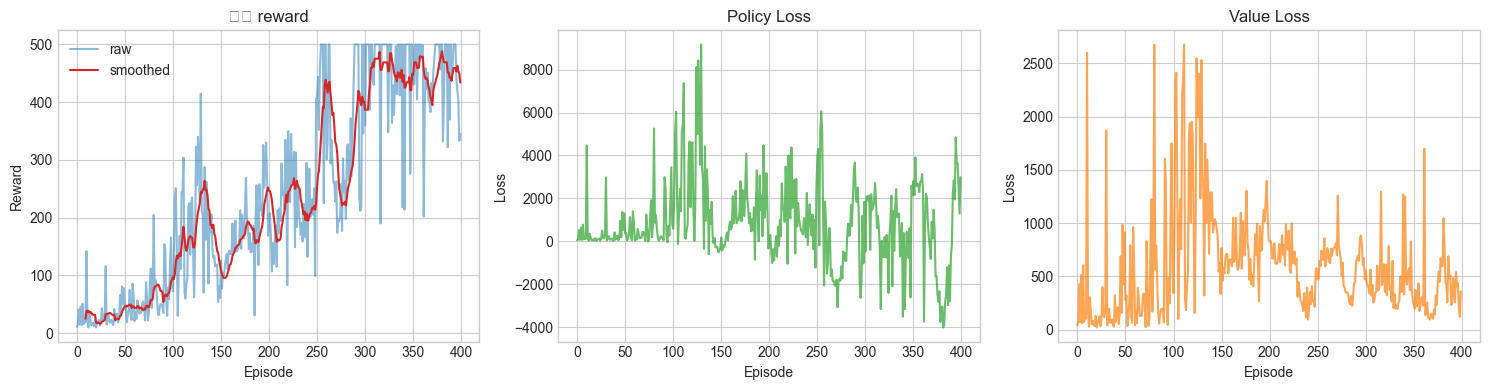

In [8]:
window = 10
smoothed_rewards = np.convolve(episode_rewards, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(episode_rewards, color='#1f77b4', alpha=0.5, label='raw')
axes[0].plot(range(window - 1, len(episode_rewards)), smoothed_rewards, color='#d62728', label='smoothed')
axes[0].set_title('每轮 reward')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Reward')
axes[0].legend()

axes[1].plot(policy_loss_history, color='#2ca02c', alpha=0.7)
axes[1].set_title('Policy Loss')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Loss')

axes[2].plot(value_loss_history, color='#ff7f0e', alpha=0.7)
axes[2].set_title('Value Loss')
axes[2].set_xlabel('Episode')
axes[2].set_ylabel('Loss')

plt.tight_layout()
plt.show()


## 6. 多次测试平均表现

测试时我们依然不采样，而是直接选当前概率最大的动作，方便观察最终策略质量。


In [9]:
test_env = gym.make('CartPole-v1')
test_rewards = []

policy_net.eval()
with torch.no_grad():
    for episode_idx in range(5):
        state, info = test_env.reset(seed=123 + episode_idx)
        test_reward = 0.0

        for step in range(500):
            state_tensor = to_tensor(state, device).unsqueeze(0)
            logits = policy_net(state_tensor)
            action = int(torch.argmax(logits, dim=1).item())

            state, reward, terminated, truncated, info = test_env.step(action)
            test_reward += reward
            if terminated or truncated:
                break

        test_rewards.append(test_reward)

print('测试 rewards:', test_rewards)
print('测试平均 reward:', round(float(np.mean(test_rewards)), 2))
test_env.close()


测试 rewards: [379.0, 319.0, 265.0, 291.0, 362.0]
测试平均 reward: 323.2


## 7. 这节课最值得记住什么

如果你想抓住这节课的主线，就记住：

- 纯 REINFORCE 用 `return` 直接更新策略
- 加了 baseline 以后，用的是 `advantage = return - baseline`

这样做的核心收益是：

**更新信号更像“比预期好多少”，而不是单纯“最后拿了多少分”。**


## 8. 下一课最自然学什么

学完这一课后，最自然的下一步就是：
- `Actor-Critic`

因为你现在已经有了：
- 一个 policy 网络
- 一个 value 网络

这其实已经很接近 Actor-Critic 的基本结构了。
